# Using PatchTST-FM

This is an example for using PatchTST-FM with the `timecopilot` library.

In [1]:
import nest_asyncio

nest_asyncio.apply()

In [2]:
import pandas as pd
from timecopilot import TimeCopilot, TimeCopilotForecaster
from timecopilot.models.foundation.patchtst_fm import PatchTSTFM

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


## Setup the model

In [3]:
model = PatchTSTFM()

## Create a TimeCopilot instance with PatchTST-FM

In [4]:
tc = TimeCopilot(
    llm="openai:gpt-4o",
    forecasters=[
        model
    ]
)

## Forecasting 

Once setup is complete, you can generate forecasts with patchTST-FM.

In [5]:
df = pd.read_csv("https://timecopilot.s3.amazonaws.com/public/data/air_passengers.csv")

In [6]:
result = tc.forecast(
    df=df,
)

INFO:p-63174:t-8427712640:_client.py:_send_single_request:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
0it [00:00, ?it/s]INFO:p-63174:t-8427712640:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 24 
100%|██████████| 1/1 [00:00<00:00,  2.24it/s]
1it [00:01,  1.84s/it]
1it [00:00, 253.82it/s]
INFO:p-63174:t-8427712640:_client.py:_send_single_request:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
100%|██████████| 1/1 [00:00<00:00,  2.77it/s]
INFO:p-63174:t-8427712640:_client.py:_send_single_request:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
0it [00:00, ?it/s]INFO:p-63174:t-8427712640:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 12 
100%|██████████| 1/1 [00:00<00:00,  2.72it/s]
1it [00:00,  1.66it/s]INFO:p-63174:t-8427712640:modeling_patchtst_fm.py:forward:Context Len: 8192 | Forecast Len: 12 
100%|██████████| 1/1 [00:00<00:00,  2.76it/s]
2it [00:0

In [7]:
print(result.output.tsfeatures_analysis)

The time series 'AirPassengers' indicates strong seasonality, as evidenced by a seasonal strength of 0.9815. The ACF1 value is high (0.948), reflecting strong autocorrelation which is typical in seasonal series. The unit root KPSS statistic (2.739) suggests non-stationarity. The entropy is low (0.429), indicating low randomness, while STL decomposition identifies a clear seasonal component with a period of 12 (monthly data).


In [8]:
result.fcst_df

,unique_id,ds,PatchTST-FM
0,AirPassengers,1961-01-01,455.369843
1,AirPassengers,1961-02-01,426.025330
2,AirPassengers,1961-03-01,480.801575
3,AirPassengers,1961-04-01,489.973755
4,AirPassengers,1961-05-01,507.733276
5,AirPassengers,1961-06-01,591.214844
6,AirPassengers,1961-07-01,677.264404
7,AirPassengers,1961-08-01,672.098755
8,AirPassengers,1961-09-01,576.013306
9,AirPassengers,1961-10-01,489.467194


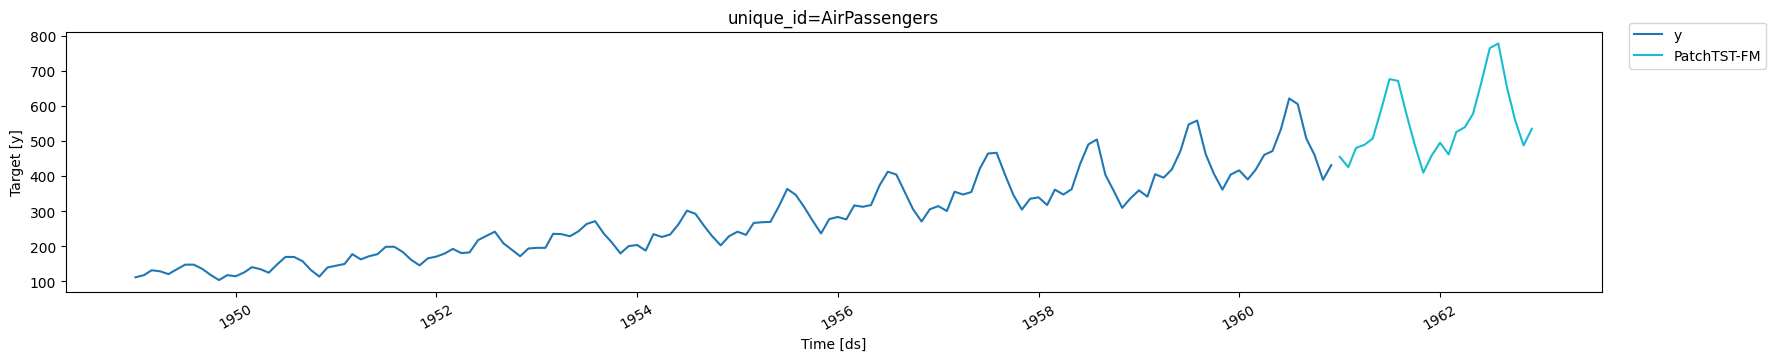

In [9]:
tcf = TimeCopilotForecaster(
    models=[
        model
    ]
)
tcf.plot(df, result.fcst_df)